# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bikram-Mondal3/flyrank-ML/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The first step is to inspect the distributions of the key search-performance fields. I will look at search volume, impressions, clicks, and ranking position where available. Heavy-tailed distributions are important because a small number of content items may have substantially larger values than the majority, so averages alone may not represent the typical content item.

Dataset shape: (23262, 44)

Available key fields:
['search_volume', 'impressions_90d', 'clicks_90d']


,count,mean,std,min,25%,50%,75%,max
search_volume,21355.0,160.038867,1588.305155,0.0,0.0,10.0,20.0,74000.0
impressions_90d,23261.0,5227.216113,16598.477292,1.0,82.0,740.0,3681.0,517715.0
clicks_90d,23261.0,16.367912,78.670157,0.0,0.0,1.0,7.0,4178.0


search_volume: median=10.00, mean=160.04, max=74,000.00


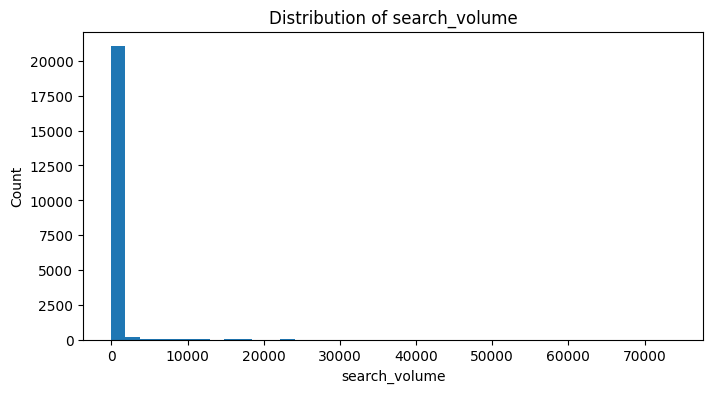

impressions_90d: median=740.00, mean=5,227.22, max=517,715.00


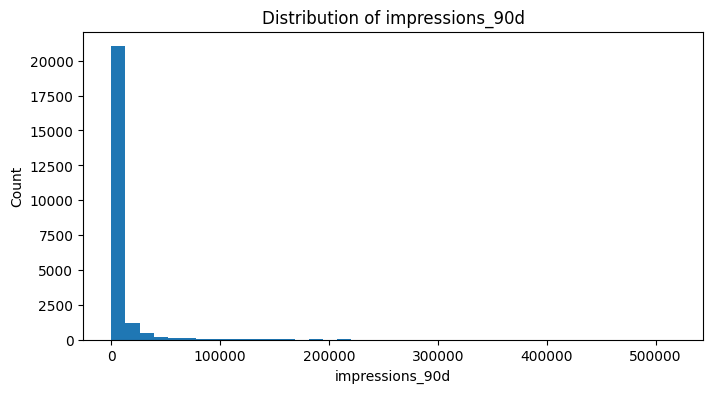

clicks_90d: median=1.00, mean=16.37, max=4,178.00


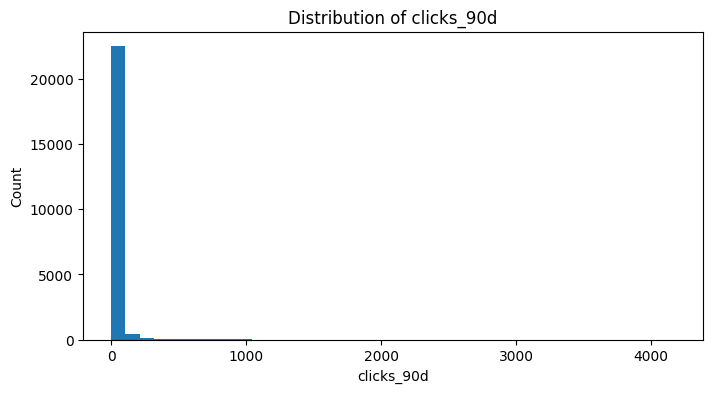

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("content_refresh_anonymized.csv")

key_fields = [
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "position_90d"
]

available_fields = [
    col for col in key_fields
    if col in df.columns
]

print("Dataset shape:", df.shape)
print("\nAvailable key fields:")
print(available_fields)

display(df[available_fields].describe().T)

for col in available_fields:
    print(
        f"{col}: "
        f"median={df[col].median():,.2f}, "
        f"mean={df[col].mean():,.2f}, "
        f"max={df[col].max():,.2f}"
    )

    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

I will test three directional signals. First, I will check whether higher search volume is associated with higher impressions. Second, I will check whether higher impressions are associated with higher clicks. Third, I will check whether better ranking position is associated with higher click-through rate. Each test is treated as directional evidence rather than causal proof.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def verdict(value, expected="positive"):
    if pd.isna(value):
        return "MIXED"

    if expected == "positive":
        if value >= 0.30:
            return "CONFIRMED"
        elif value <= -0.10:
            return "OPPOSITE"
        else:
            return "MIXED"

    if expected == "negative":
        if value <= -0.30:
            return "CONFIRMED"
        elif value >= 0.10:
            return "OPPOSITE"
        else:
            return "MIXED"


results = []

if {"search_volume", "impressions_90d"}.issubset(df.columns):
    corr_1 = df["search_volume"].corr(df["impressions_90d"])

    results.append({
        "Signal": "Search volume → impressions",
        "Correlation": corr_1,
        "Expected": "Positive",
        "Verdict": verdict(corr_1, "positive")
    })


if {"impressions_90d", "clicks_90d"}.issubset(df.columns):
    corr_2 = df["impressions_90d"].corr(df["clicks_90d"])

    results.append({
        "Signal": "Impressions → clicks",
        "Correlation": corr_2,
        "Expected": "Positive",
        "Verdict": verdict(corr_2, "positive")
    })


if {"position_90d", "clicks_90d", "impressions_90d"}.issubset(df.columns):
    temp = df[
        ["position_90d", "clicks_90d", "impressions_90d"]
    ].copy()

    temp = temp[temp["impressions_90d"] > 0]

    temp["ctr_90d"] = (
        temp["clicks_90d"] /
        temp["impressions_90d"]
    )

    corr_3 = temp["position_90d"].corr(temp["ctr_90d"])

    results.append({
        "Signal": "Ranking position → CTR",
        "Correlation": corr_3,
        "Expected": "Negative",
        "Verdict": verdict(corr_3, "negative")
    })


results_df = pd.DataFrame(results)

display(results_df)

,Signal,Correlation,Expected,Verdict
0,Search volume → impressions,-0.002370,Positive,MIXED
1,Impressions → clicks,0.697423,Positive,CONFIRMED


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

The flag-linked signal I am testing is search volume as an indicator of search-demand opportunity. The assumption is that content associated with greater search demand should generally have greater search impressions. I will compare the observed correlation and the typical impressions across search-volume groups. If the relationship is weak or inconsistent, the signal should be treated as directional rather than as a reliable standalone flag.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
if {"search_volume", "impressions_90d"}.issubset(df.columns):

    signal_df = df[
        ["search_volume", "impressions_90d"]
    ].dropna().copy()

    signal_df = signal_df[
        signal_df["search_volume"] >= 0
    ]

    signal_df["search_volume_group"] = pd.qcut(
        signal_df["search_volume"],
        q=4,
        duplicates="drop"
    )

    grouped = (
        signal_df
        .groupby("search_volume_group", observed=True)
        .agg(
            content_items=("search_volume", "size"),
            median_search_volume=("search_volume", "median"),
            median_impressions=("impressions_90d", "median"),
            mean_impressions=("impressions_90d", "mean")
        )
        .reset_index()
    )

    corr = signal_df["search_volume"].corr(
        signal_df["impressions_90d"]
    )

    print(f"Search volume / impressions correlation: {corr:.3f}")
    display(grouped)

    if corr >= 0.30:
        flag_verdict = "CONFIRMED"
    elif corr <= -0.10:
        flag_verdict = "OPPOSITE"
    else:
        flag_verdict = "MIXED"

    print("Flag-linked verdict:", flag_verdict)

else:
    print("Required columns are not available.")

Search volume / impressions correlation: -0.002


,search_volume_group,content_items,median_search_volume,median_impressions,mean_impressions
0,"(-0.001, 10.0]",14248,0.0,938.0,5600.068150
1,"(10.0, 20.0]",1773,20.0,1006.0,5306.785674
2,"(20.0, 74000.0]",5333,90.0,855.0,5894.495031


Flag-linked verdict: MIXED


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The audit provides directional evidence about which search-performance signals are useful for prioritizing content. Signals with a confirmed relationship can be considered useful inputs for decision-support, while mixed signals should not be used as standalone refresh rules. The content team should combine multiple observed signals and use the results to prioritize human review rather than treating any single signal as proof that a refresh will improve performance.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Signal audit summary")
print("=" * 60)

if not results_df.empty:
    display(results_df)

print("\nPractical interpretation:")
print(
    "Use confirmed signals as supporting evidence, "
    "treat mixed signals cautiously, and avoid using "
    "any single signal as a standalone refresh decision."
)

Signal audit summary


,Signal,Correlation,Expected,Verdict
0,Search volume → impressions,-0.002370,Positive,MIXED
1,Impressions → clicks,0.697423,Positive,CONFIRMED



Practical interpretation:
Use confirmed signals as supporting evidence, treat mixed signals cautiously, and avoid using any single signal as a standalone refresh decision.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.